# Forecast Error Analysis

This notebook analyses UK national wind forecast performance using the
challenge rule: for each target time, select the latest forecast
published at least `h` hours before delivery.


## Method

1. Load cached analysis data from `analysis/data/`.
2. If cached data does not exist, optionally fetch and rebuild it from BMRS.
3. Evaluate signed error and absolute error overall, by forecast horizon, and by hour of day.


In [18]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
def find_repo_root() -> Path:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for candidate in candidates:
        if (candidate / "analysis" / "fetch_data" / "pipeline.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root containing analysis/fetch_data/pipeline.py")
ROOT = find_repo_root()
DATA_DIR = ROOT / "analysis" / "data"
FETCH_DIR = ROOT / "analysis" / "fetch_data"
if str(FETCH_DIR) not in sys.path:
    sys.path.append(str(FETCH_DIR))
from pipeline import fetch_clean_and_join, save_datasets
sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:,.2f}".format
REFRESH_DATA = True
PUBLISH_FROM = "2024-01-01T00:00:00Z"
PUBLISH_TO = "2026-01-02T00:00:00Z"

In [19]:
joined_path = DATA_DIR / "joined_forecasts_actuals.csv"

if REFRESH_DATA or not joined_path.exists():
    actuals, forecasts, joined = fetch_clean_and_join(
        publish_from=PUBLISH_FROM,
        publish_to=PUBLISH_TO,
    )
    save_datasets(actuals, forecasts, joined, output_dir=DATA_DIR)
else:
    joined = pd.read_csv(joined_path, parse_dates=["target_time", "publish_time"])
joined["error_mw"] = joined["forecast_mw"] - joined["actual_mw"]
joined["abs_error_mw"] = joined["error_mw"].abs()
print("Rows:", len(joined))
print("Target time range:", joined["target_time"].min(), "to", joined["target_time"].max())
joined.head()

WINDFOR columns: ['dataset', 'publishTime', 'startTime', 'generation']
FUELHH columns: ['dataset', 'publishTime', 'startTime', 'settlementDate', 'settlementPeriod', 'fuelType', 'generation']
Rows: 815819
Target time range: 2024-01-01 21:00:00+00:00 to 2026-01-01 23:00:00+00:00


,target_time,actual_mw,publish_time,forecast_mw,horizon_hours,horizon,error,abs_error,hour,day_of_week,month,error_mw,abs_error_mw
0,2024-01-01 21:00:00+00:00,13953,2024-01-01 18:30:00+00:00,11730,2.50,0,-2223,2223,21,0,1,-2223,2223
1,2024-01-01 22:00:00+00:00,14217,2024-01-01 18:30:00+00:00,13120,3.50,0,-1097,1097,22,0,1,-1097,1097
2,2024-01-01 23:00:00+00:00,14958,2024-01-01 22:30:00+00:00,14426,0.50,0,-532,532,23,0,1,-532,532
3,2024-01-02 00:00:00+00:00,14690,2024-01-01 22:30:00+00:00,15364,1.50,0,674,674,0,1,1,674,674
4,2024-01-02 01:00:00+00:00,14592,2024-01-01 22:30:00+00:00,15807,2.50,0,1215,1215,1,1,1,1215,1215


## Overall error summary

Signed error shows whether the forecast tends to over- or under-predict.
Absolute error captures magnitude regardless of direction.


In [20]:
overall_summary = pd.DataFrame(
    {
        "metric": [
            "mean_signed_error_mw",
            "median_signed_error_mw",
            "mean_abs_error_mw",
            "median_abs_error_mw",
            "p99_abs_error_mw",
        ],
        "value": [
            joined["error_mw"].mean(),
            joined["error_mw"].median(),
            joined["abs_error_mw"].mean(),
            joined["abs_error_mw"].median(),
            joined["abs_error_mw"].quantile(0.99),
        ],
    }
)
overall_summary


,metric,value
0,mean_signed_error_mw,"1,213.28"
1,median_signed_error_mw,976.00
2,mean_abs_error_mw,"1,590.22"
3,median_abs_error_mw,"1,197.00"
4,p99_abs_error_mw,"5,780.82"


## Error by forecast horizon

This is the core behavioural view. If the selection logic is working,
errors should generally worsen as the required look-ahead horizon grows.


In [21]:
horizon_summary = (
    joined.groupby("horizon")
    .agg(
        sample_count=("target_time", "size"),
        mean_signed_error_mw=("error_mw", "mean"),
        median_signed_error_mw=("error_mw", "median"),
        mean_abs_error_mw=("abs_error_mw", "mean"),
        median_abs_error_mw=("abs_error_mw", "median"),
        p99_abs_error_mw=("abs_error_mw", lambda s: s.quantile(0.99)),
    )
    .reset_index()
)
horizon_summary.head(10)


,horizon,sample_count,mean_signed_error_mw,median_signed_error_mw,mean_abs_error_mw,median_abs_error_mw,p99_abs_error_mw
0,0,17547,"1,162.83",839.00,"1,402.53",969.00,"5,716.54"
1,1,17547,"1,164.64",843.00,"1,405.25",973.00,"5,709.56"
2,2,17547,"1,172.32",856.00,"1,410.56",981.00,"5,725.18"
3,3,17547,"1,180.59",871.00,"1,418.16",996.00,"5,710.34"
4,4,17547,"1,187.38",887.00,"1,427.92","1,007.00","5,684.70"
5,5,17547,"1,190.81",894.00,"1,436.79","1,016.00","5,673.50"
6,6,17547,"1,192.92",902.00,"1,446.25","1,031.00","5,652.08"
7,7,17547,"1,195.39",912.00,"1,455.37","1,042.00","5,649.62"
8,8,17547,"1,198.19",918.00,"1,463.28","1,055.00","5,652.08"
9,9,17547,"1,201.34",924.00,"1,470.97","1,070.00","5,695.78"


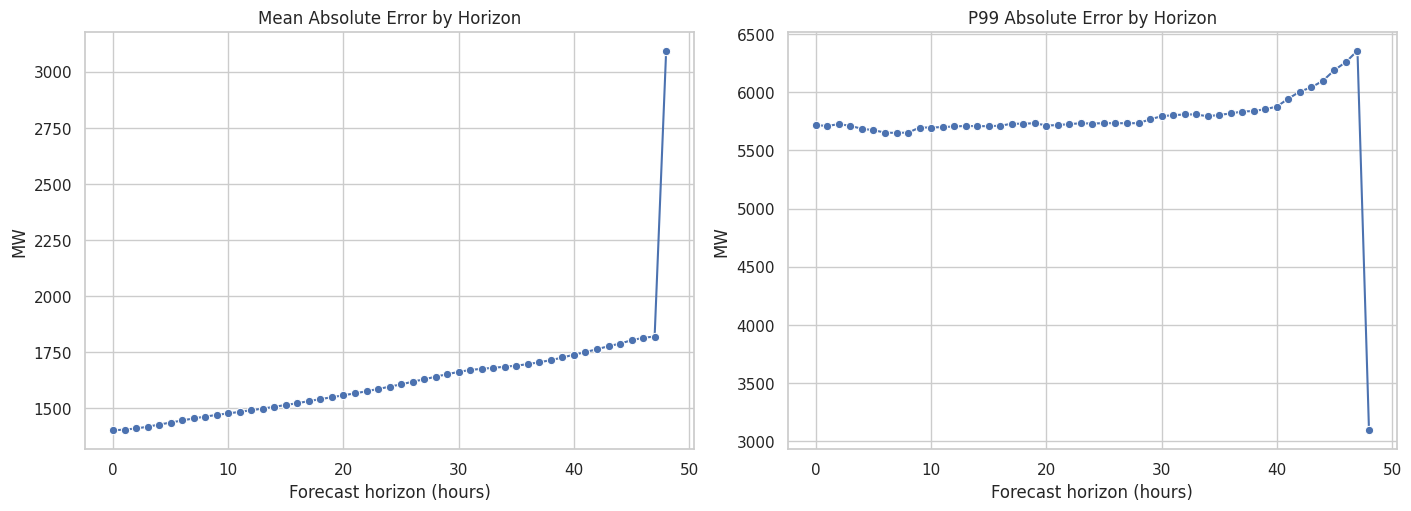

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.lineplot(
    data=horizon_summary,
    x="horizon",
    y="mean_abs_error_mw",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Mean Absolute Error by Horizon")
axes[0].set_xlabel("Forecast horizon (hours)")
axes[0].set_ylabel("MW")
sns.lineplot(
    data=horizon_summary,
    x="horizon",
    y="p99_abs_error_mw",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("P99 Absolute Error by Horizon")
axes[1].set_xlabel("Forecast horizon (hours)")
axes[1].set_ylabel("MW")
plt.show()


## Error by time of day

This view checks whether some delivery hours are materially harder
to predict than others.


In [23]:
hour_summary = (
    joined.groupby("hour")
    .agg(
        sample_count=("target_time", "size"),
        mean_abs_error_mw=("abs_error_mw", "mean"),
        median_abs_error_mw=("abs_error_mw", "median"),
        p99_abs_error_mw=("abs_error_mw", lambda s: s.quantile(0.99)),
    )
    .reset_index()
)
hour_summary


,hour,sample_count,mean_abs_error_mw,median_abs_error_mw,p99_abs_error_mw
0,0,33182,"1,621.92","1,215.00","5,732.00"
1,1,33913,"1,635.54","1,224.00","5,833.00"
2,2,34644,"1,655.73","1,256.00","5,853.00"
3,3,34755,"1,680.38","1,265.00","5,936.06"
4,4,34646,"1,718.79","1,294.50","6,094.00"
5,5,34447,"1,696.64","1,292.00","6,048.10"
6,6,33918,"1,675.25","1,274.00","6,039.00"
7,7,34649,"1,641.70","1,253.00","5,987.00"
8,8,34760,"1,602.62","1,203.50","5,888.00"
9,9,34643,"1,592.84","1,169.00","5,850.00"


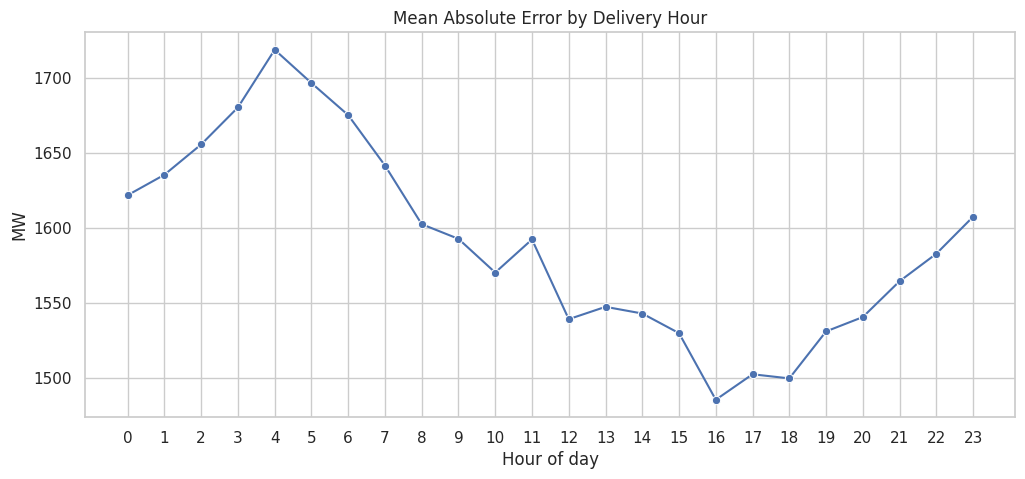

In [24]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=hour_summary, x="hour", y="mean_abs_error_mw", marker="o")
plt.title("Mean Absolute Error by Delivery Hour")
plt.xlabel("Hour of day")
plt.ylabel("MW")
plt.xticks(range(24))
plt.show()


## Interpretation checklist

Use the computed tables and plots above to answer:
- Is there a material signed bias overall?
- How quickly does error grow with horizon?
- Which hours of day are the least reliable?
- Is the tail risk small enough for your intended operational use?
